House Price Prediction

Importing Dependencies

In [85]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder , StandardScaler
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn import metrics


Data Collection and Analysis

In [86]:
house_data = pd.read_csv("Housing.csv")

In [87]:
house_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [88]:
house_data.shape

(545, 13)

In [89]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [90]:
house_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [91]:
house_data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Encoding Categorical Data

In [92]:
object_columns = list(house_data.select_dtypes("object").columns)
print(object_columns)

['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [93]:
encoder = LabelEncoder()

def encoding_categorical_data(df , column_name):
    df[column_name] = encoder.fit_transform(df[column_name])

for i in object_columns:
    encoding_categorical_data(house_data ,i)


In [94]:
house_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


Data Visualization

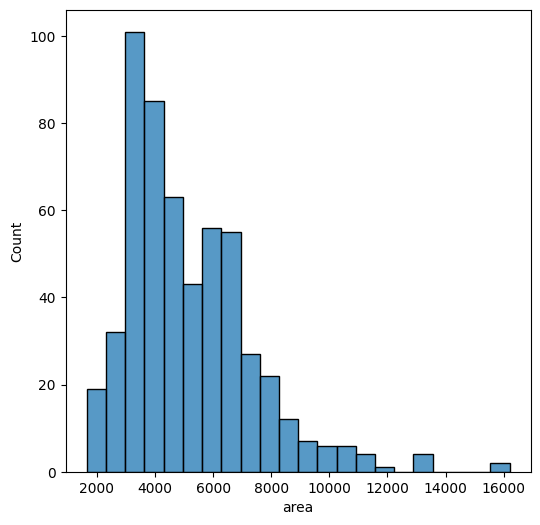

In [95]:
plt.figure(figsize=(6,6))
sns.histplot(x="area",data=house_data)
plt.show()

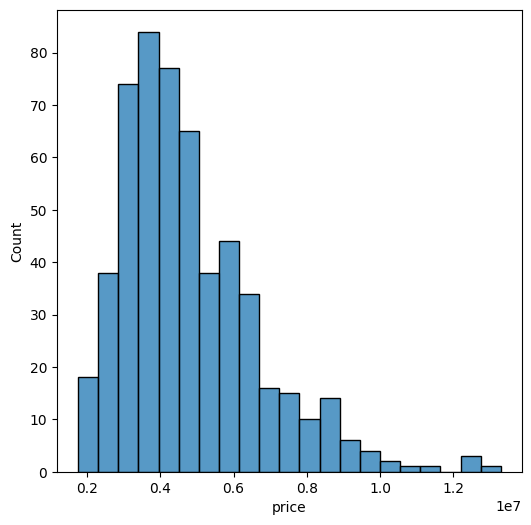

In [96]:
plt.figure(figsize=(6,6))
sns.histplot(x="price",data=house_data)
plt.show()

Heatmap

In [97]:
correlation = house_data.corr()

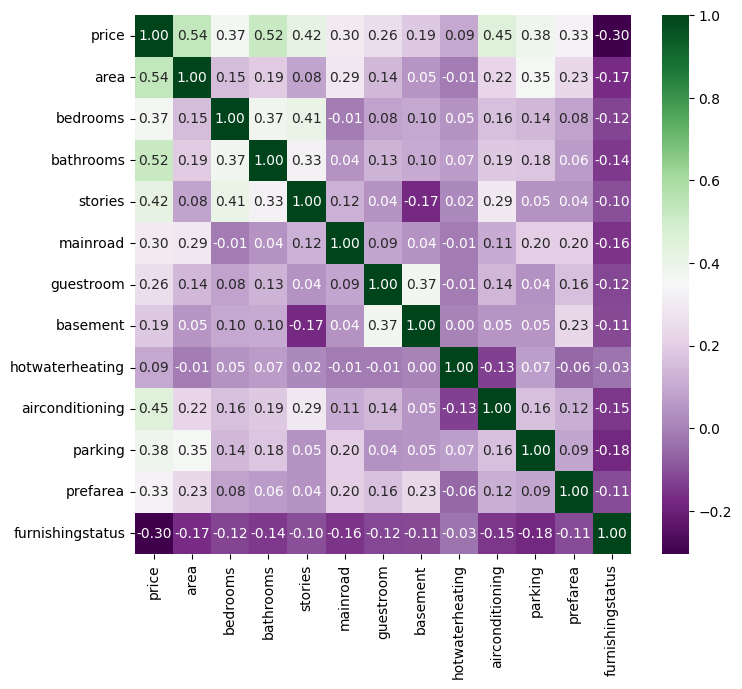

In [98]:
plt.figure(figsize=(8,7))
sns.heatmap(correlation , annot=True ,annot_kws={"size":10} ,cmap="PRGn", fmt=".2f")
plt.show()

Separating Features and Targets

In [99]:
x = house_data.drop(columns="price", axis=1)

print(x)

     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0    7420         4          2        3         1          0         0   
1    8960         4          4        4         1          0         0   
2    9960         3          2        2         1          0         1   
3    7500         4          2        2         1          0         1   
4    7420         4          1        2         1          1         1   
..    ...       ...        ...      ...       ...        ...       ...   
540  3000         2          1        1         1          0         1   
541  2400         3          1        1         0          0         0   
542  3620         2          1        1         1          0         0   
543  2910         3          1        1         0          0         0   
544  3850         3          1        2         1          0         0   

     hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                  0              

In [100]:
y = house_data["price"]

print(y)

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64


Splitting data into training data and test data

In [101]:
x_train , x_test , y_train , y_test = train_test_split(x , y, test_size=0.2 , random_state=42)

In [102]:
x.shape , x_train.shape , x_test.shape

((545, 12), (436, 12), (109, 12))

Hyperparameter Tuning & Model Training

Building a Pipeline

In [103]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',XGBRegressor(ranodm_state=42, objective='reg:squarederror'))
])

Defining the Hyperparameter search space

In [104]:
param_distributions = {
    'model__num_parallel_tree':[15],
    'model__n_estimators':[80],
    'model__max_depth':[3,4],
    'model__learning_rate':[0.05,0.1],
    'model__subsample':[0.6,0.7],
    'model__colsample_bytree':[0.6,0.7],
    'model__min_child_weight':[5,10],
    'model__reg_alpha':[0.1,1.0,5.0],
    'model__reg_lambda':[10.0,20.0],
    'model__max_leaves':[7,15,31],
    'model__gamma':[0.5,1.0,2.0]
}

Initialize RandomizedSearchCV

In [105]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions = param_distributions,
    n_iter=20,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs =-1
)

In [106]:
random_search.fit(x_train , y_train)

c:\Users\Rajasekar\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:34:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "ranodm_state" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.7], 'model__gamma': [0.5, 1.0, ...], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 4], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [107]:
print("Best Hyperparameters found :", random_search.best_params_)

Best Hyperparameters found : {'model__subsample': 0.7, 'model__reg_lambda': 10.0, 'model__reg_alpha': 0.1, 'model__num_parallel_tree': 15, 'model__n_estimators': 80, 'model__min_child_weight': 5, 'model__max_leaves': 15, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 1.0, 'model__colsample_bytree': 0.6}


Model Evaluation using R Squared Error

In [108]:
best_model = random_search.best_estimator_

In [109]:
x_train_prediction = best_model.predict(x_train)

In [110]:
train_r2_score = metrics.r2_score(y_train , x_train_prediction)

print("R Squared Error :",train_r2_score)

R Squared Error : 0.8132284283638


In [111]:
x_test_prediction = best_model.predict(x_test)

In [112]:
test_r2_score = metrics.r2_score(y_test ,x_test_prediction)

print("R Squared Error :" ,test_r2_score)

R Squared Error : 0.6364333629608154
